In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Value:

    def __init__(self,data,_parents=(),_op = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_parents)
        self._op = _op
        
    def __repr__(self):
        return f"Value(data={self.data}) , grad={self.grad})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        s = Value(self.data + other.data,(self,other),'+')

        def _backward():
            self.grad += s.grad
            other.grad += s.grad
        s._backward = _backward
        return s

    def __radd__(self, other):
        return self+other

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        prod = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * prod.grad
            other.grad += self.data * prod.grad
        prod._backward = _backward
        return prod

    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out = Value(self.data**other,(self,),'**')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        return self * other**-1

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1

    def __rsub__(self, other):
        return other + (-self)

    def __rtruediv__(self, other):
        return other * self**-1

    def zero_grad(self):
        self.grad = 0.0

    def tanh(self):
        n = self.data
        o = (math.exp(2*n)-1)/(math.exp(2*n) + 1)
        out = Value(o,(self,),'tanh')

        def _backward():
            self.grad += (1 - o**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        n = self.data
        o = math.exp(n)
        out = Value(o,(self,),'exp')

        def _backward():
            self.grad += o * out.grad
        out._backward = _backward
        return out

    def relu(self):
        n = self.data
        o = n if n > 0 else 0
        out = Value(o,(self,),'relu')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out
    
    def print_graph(self):
        visited = set()
        def print_nodes(v, depth=0):
            if v in visited:
                return
            visited.add(v)
            print(
                "  " * depth +
                f"Value(data={v.data:.4f}, grad={v.grad:.4f}, op='{v._op}')"
            )

            for parent in v._prev:
                print_nodes(parent, depth + 1)

        print_nodes(self)
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for parent in v._prev:
                    build_topo(parent)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



In [3]:
a = Value(2.0)
b = Value(3.0)

c = a * b
c.backward()

print("a.grad =", a.grad)
print("b.grad =", b.grad)

a.grad = 3.0
b.grad = 2.0


In [4]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(np.random.randn()) for _ in range(nin)]
        self.b = Value(np.random.randn())

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        params =[]
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params

    def summary(self):
        print("-------MLP Summary-------")
        print("---------------------------")

        for i , layers in enumerate(self.layers):
            print(f"Layer {i+1}:")
            for j, neuron in enumerate(layers.neurons):
                print(f"  Neuron {j+1}:")
                for k, w in enumerate(neuron.w):
                    print(f"    Weight {k+1}: {w.data:.4f}")
                print(f"    Bias: {neuron.b.data:.4f}")
            print("---------------------------")

In [5]:
xs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
]

ys = [
    0.0,
    1.0,
    1.0,
    0.0
]

In [6]:
model = MLP(2, [4, 4, 1])
model.summary()

-------MLP Summary-------
---------------------------
Layer 1:
  Neuron 1:
    Weight 1: -0.1744
    Weight 2: 0.3363
    Bias: -2.2800
  Neuron 2:
    Weight 1: 2.2788
    Weight 2: 0.6970
    Bias: 0.0909
  Neuron 3:
    Weight 1: 0.2654
    Weight 2: 0.1834
    Bias: -0.9832
  Neuron 4:
    Weight 1: -0.6330
    Weight 2: 0.3011
    Bias: -1.3698
---------------------------
Layer 2:
  Neuron 1:
    Weight 1: -1.4262
    Weight 2: -2.0410
    Weight 3: -0.0099
    Weight 4: 0.0668
    Bias: 0.2331
  Neuron 2:
    Weight 1: 0.0642
    Weight 2: 0.0905
    Weight 3: -0.0304
    Weight 4: -0.5617
    Bias: 0.8280
  Neuron 3:
    Weight 1: 2.0377
    Weight 2: -0.4276
    Weight 3: -1.3752
    Weight 4: 0.7141
    Bias: -0.0024
  Neuron 4:
    Weight 1: 1.1782
    Weight 2: 1.2332
    Weight 3: 0.2807
    Weight 4: 2.3103
    Bias: 0.2509
---------------------------
Layer 3:
  Neuron 1:
    Weight 1: -0.7104
    Weight 2: -0.8642
    Weight 3: 1.7127
    Weight 4: -1.2698
    Bias: -0.13

In [7]:
def train(model, xs, ys, epochs=100, lr=0.1):
    history = []

    for epoch in range(epochs):
        predictions = [model(x) for x in xs]

        loss = sum((yp - y)**2 for yp, y in zip(predictions, ys))

        for p in model.parameters():
            p.grad = 0.0

        loss.backward()

        for p in model.parameters():
            p.data -= lr * p.grad

        history.append(loss.data)

    return history

def predict(model, x):
    return model(x).data

In [8]:
history = train(model, xs, ys, epochs=100, lr=0.1)
for x, y in zip(xs, ys):
    print(f"Input: {x}, Prediction: {predict(model, x):.4f}, Target: {y}")

Input: [0.0, 0.0], Prediction: 0.0188, Target: 0.0
Input: [0.0, 1.0], Prediction: 0.9213, Target: 1.0
Input: [1.0, 0.0], Prediction: 0.8939, Target: 1.0
Input: [1.0, 1.0], Prediction: 0.0024, Target: 0.0


In [9]:
print("Predictions:")

for x, y in zip(xs, ys):
    prediction = model(x)
    print(f"{x} -> {prediction.data:.4f}  target={y}")

Predictions:
[0.0, 0.0] -> 0.0188  target=0.0
[0.0, 1.0] -> 0.9213  target=1.0
[1.0, 0.0] -> 0.8939  target=1.0
[1.0, 1.0] -> 0.0024  target=0.0


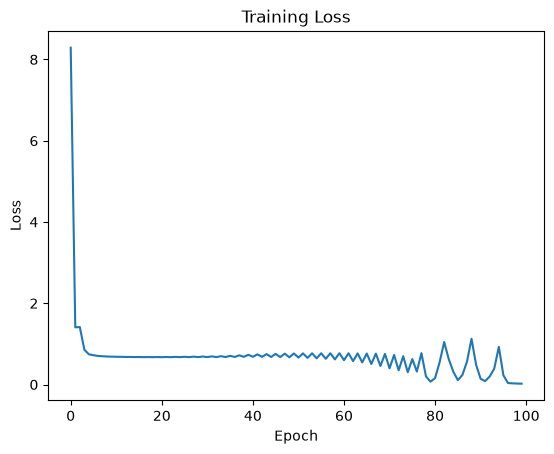

In [10]:
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()